# Model Training 

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

from data_loading import load_data
from preprocessing import preprocess_pipeline
from train import train_model, save_model
from evaluate import evaluate_model, plot_confusion_matrix

In [2]:
df = load_data()
df = preprocess_pipeline(df)

Data loaded: (590540, 434)
Dropping 12 high-missing columns
Encoded 29 categorical columns
Starting feature engineering...
Feature engineering completed
Preprocessing completed


# Train

In [3]:
model, X_val, y_val = train_model(df)

Starting training...
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.127485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39694
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 426
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
Training completed


# Evaluate

In [4]:
evaluate_model(model, X_val, y_val)

AUC Score: 0.9674437690803592

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.96      0.61      0.74      4133

    accuracy                           0.99    118108
   macro avg       0.97      0.80      0.87    118108
weighted avg       0.98      0.99      0.98    118108



0.9674437690803592

# Confusion Matrix

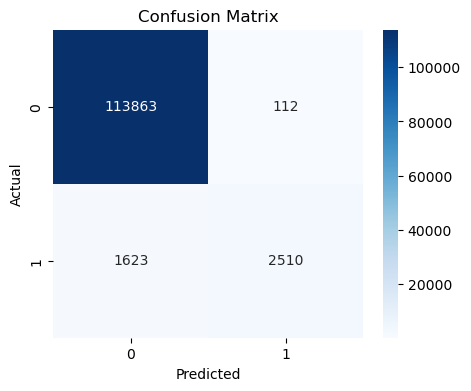

array([[113863,    112],
       [  1623,   2510]])

In [5]:
plot_confusion_matrix(model, X_val, y_val)

# Save Baseline Model

In [7]:
save_model(model, "baseline_lightgbm.pkl")

Model saved at: ../models/baseline_lightgbm.pkl
